In [2]:
import torch
import torchvision.models as models
import torchlens as tl

In [4]:
model = models.resnet18(weights="IMAGENET1K_V1").eval()  # .eval(): pretrained models arrive
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

ResNet | input (1, 3, 224, 224) float32
view: module tree, depth 2 of 4, 1 fold, 1 root-level ops in totals
name (type)                  output              params        (%)  fwd flops
-----------------------------------------------------------------------------
conv1 (Conv2d)               (1, 64, 112, 112)    9.41K   ... 0.1%    236.03M
bn1 (BatchNorm2d)            (1, 64, 112, 112)      128   ... 0.0%      4.01M
relu (ReLU)                  (1, 64, 112, 112)        -          -    802.82K
maxpool (MaxPool2d)          (1, 64, 56, 56)          -          -    602.11K
layer1 (Sequential)          (1, 64, 56, 56)    147.97K   ... 1.3%    930.06M
  0..1 (BasicBlock x2)       (1, 64, 56, 56)    147.97K   ... 1.3%    930.06M
layer2 (Sequential)          (1, 128, 28, 28)   525.57K   ... 4.5%    825.19M
  0 (BasicBlock)             (1, 128, 28, 28)   230.14K   ... 2.0%    361.47M
  1 (BasicBlock)             (1, 128, 28, 28)   295.42K   ... 2.5%    463.73M
layer3 (Sequential)          (1, 2

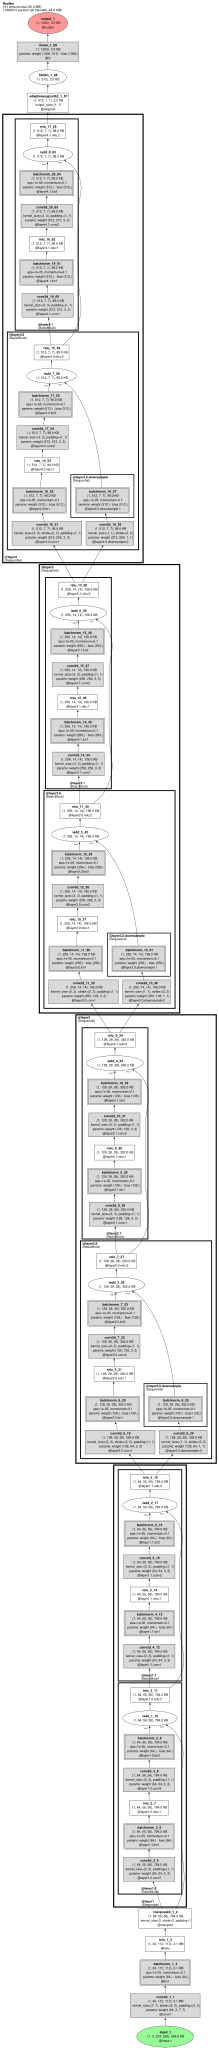

'// Computational graph for the feedforward sweep\ndigraph ResNet {\n\tgraph [bgcolor=white fontname=Helvetica label=<<FONT COLOR=\'black\'><B>ResNet</B><br align=\'left\'/>151 tensors total (32.0 MB)<br align=\'left\'/>11689512 params (all trainable, 44.6 MB)<br align=\'left\'/></FONT>> labeljust=left labelloc=t ordering=out rankdir=BT]\n\tnode [fontname=Helvetica ordering=out]\n\tedge [fontname=Helvetica]\n\tinput_1pass1 [label=<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2"><TR><TD ALIGN="CENTER"><B>input_1</B></TD></TR><TR><TD ALIGN="CENTER">(1, 3, 224, 224), 588.0 KB</TD></TR><TR><TD ALIGN="CENTER">@input.x</TD></TR></TABLE>> color=black fillcolor="#98FB98" fontcolor=black ordering=out shape=oval style="filled,solid"]\n\tinput_1pass1 -> conv2d_1_1pass1 [arrowsize=.7 color=black fontcolor=black labelfontsize=8 style=solid]\n\tconv2d_1_1pass1 [label=<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="2"><TR><TD ALIGN="CENTER"><B>conv2d_1_1</B></TD></TR><

In [ ]:



# in train mode, and a train-mode forward silently updates BatchNorm running statistics
x = torch.rand(1, 3, 224, 224, generator=torch.Generator().manual_seed(0))

log = tl.trace(model, x)      # one call -- full graph + all activations
print(log.summary())          # module table, op count, FLOPs
print(log["conv2d_1_1"].out.shape)  # grab any activation by name ...
print(log["layer1.0"].out.shape)    # ... or by module path
print(log[7].func_name)             # ... or by ordinal
log.draw()                    # PDF of the computational graph